Event ID                         | Phase | T_Start  | T_End    | Diff (s)
---------------------------------------------------------------------------
2023-12-31-02-11-56.537000ML1.5  | P     |     9.57 |    15.38 |     5.81
2023-12-10-06-49-27.068000ML1.4  | P     |    12.78 |    17.10 |     4.33
2023-11-18-06-42-18.743000ML1.8  | P     |    17.40 |    23.81 |     6.41
2023-10-26-02-36-59.823000ML1.3  | P     |    13.26 |    17.78 |     4.52
2023-10-03-19-50-59.443000ML1.4  | P     |    16.51 |    20.58 |     4.07
2023-09-10-03-19-28.336000ML1.4  | P     |    16.56 |    14.21 |     2.35
2023-08-18-01-19-46.681000ML1.3  | P     |    10.53 |    18.16 |     7.64
2023-07-26-06-07-07.039000ML1.2  | P     |    14.52 |    10.19 |     4.33
2023-07-03-09-42-42.845000ML1.5  | P     |    11.25 |    19.31 |     8.06
2023-06-10-07-33-00.219000ML1.9  | P     |    13.48 |    11.19 |     2.29


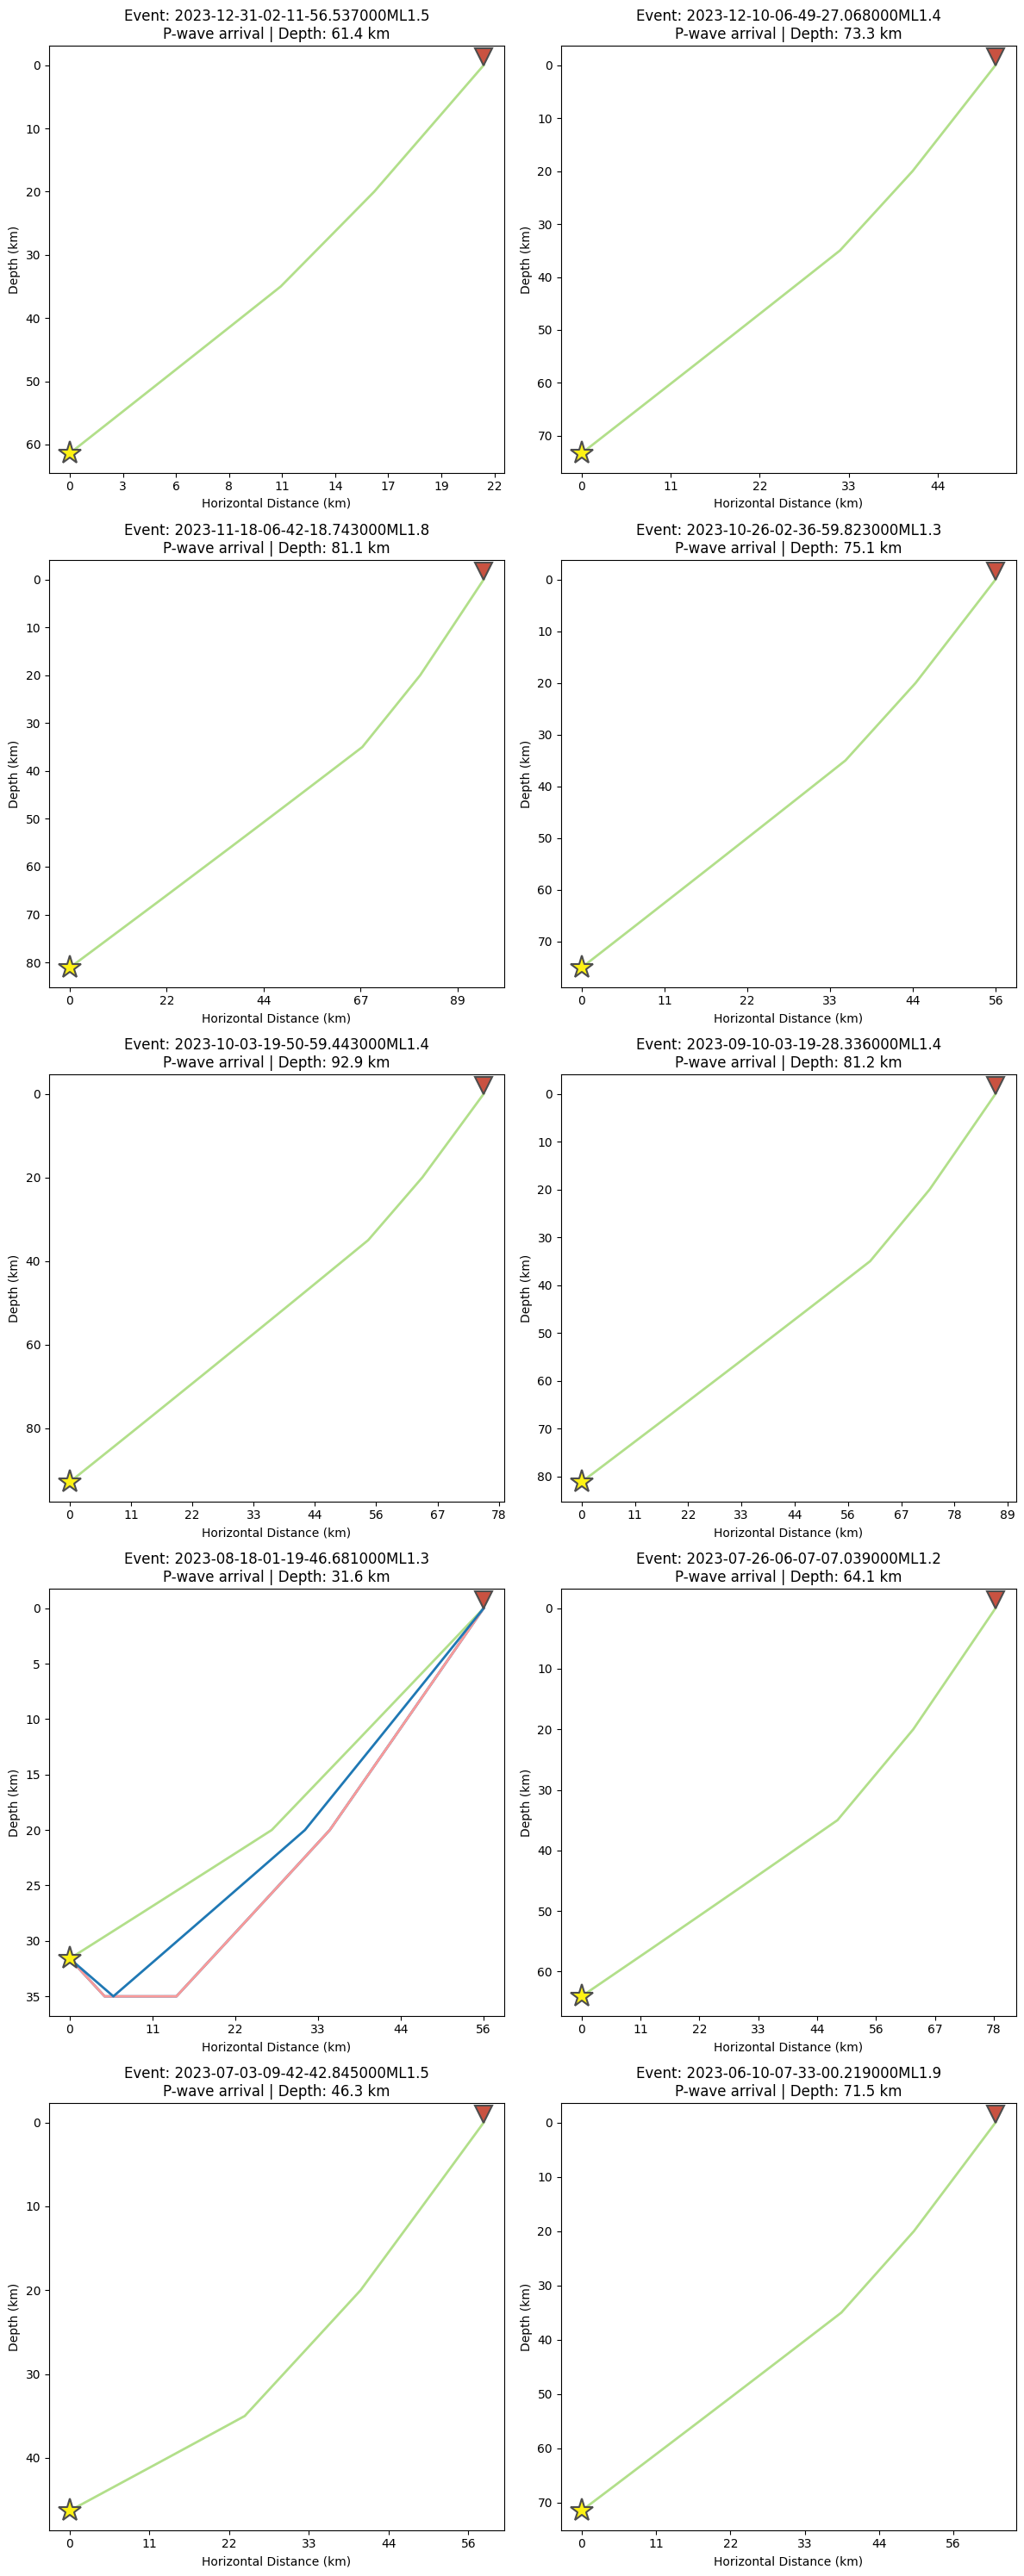

In [6]:
# TauP arrivals basic plots

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

model = TauPyModel(model="ak135")

event_data = {
    "2023-12-31-02-11-56.537000ML1.5": {"lat": 59.832, "lon": -151.569, "dep": 61400.0},
    "2023-12-10-06-49-27.068000ML1.4": {"lat": 59.929, "lon": -152.260, "dep": 73300.0},
    "2023-11-18-06-42-18.743000ML1.8": {"lat": 60.450, "lon": -152.067, "dep": 81100.0},
    "2023-10-26-02-36-59.823000ML1.3": {"lat": 59.976, "lon": -152.272, "dep": 75100.0},
    "2023-10-03-19-50-59.443000ML1.4": {"lat": 60.090, "lon": -152.540, "dep": 92900.0},
    "2023-09-10-03-19-28.336000ML1.4": {"lat": 59.297, "lon": -152.916, "dep": 81200.0},
    "2023-08-18-01-19-46.681000ML1.3": {"lat": 59.845, "lon": -150.637, "dep": 31600.0},
    "2023-07-26-06-07-07.039000ML1.2": {"lat": 59.103, "lon": -152.437, "dep": 64100.0},
    "2023-07-03-09-42-42.845000ML1.5": {"lat": 60.133, "lon": -151.232, "dep": 46300.0},
    "2023-06-10-07-33-00.219000ML1.9": {"lat": 59.262, "lon": -152.349, "dep": 71500.0}
}

event_list = list(event_data.keys())

def analyze_cable_moveout(coords_df, event_dict):
    """
    Takes the first and last seismometers on the cable, identifies a matching P or S-wave arrival for both points.
    calculates travel times for earthquakes to both points, finds the difference, outputs arrival times into 
    a neat table of Phase, T_start, T_end, and Diff(erence), and saves them to a results array.  
    """
    p1 = coords_df.iloc[0]
    p2 = coords_df.iloc[-1]
    results = []
    
    print(f"{'Event ID':<32} | {'Phase':<5} | {'T_Start':<8} | {'T_End':<8} | {'Diff (s)':<8}")
    print("-" * 75)

    for eid, info in event_data.items():
        z_km = info['dep'] / 1000.0
        dist1 = locations2degrees(info['lat'], info['lon'], p1['lat'], p1['lon'])
        dist2 = locations2degrees(info['lat'], info['lon'], p2['lat'], p2['lon'])
        
        p_phases = ["p", "P", "Pn", "Pg"]
        arr1_p = model.get_travel_times(z_km, dist1, phase_list=p_phases)
        arr2_p = model.get_travel_times(z_km, dist2, phase_list=p_phases)
        t1, t2, phase_used = None, None, None

        if len(arr1_p) > 0 and len(arr2_p) > 0:
            t1, t2 = arr1_p[0].time, arr2_p[0].time
            phase_used = "P"
        
        else:
            s_phases = ["s", "S", "Sn", "Sg"]
            arr1_s = model.get_travel_times(z_km, dist1, phase_list=s_phases)
            arr2_s = model.get_travel_times(z_km, dist2, phase_list=s_phases)
            
            if len(arr1_s) > 0 and len(arr2_s) > 0:
                t1, t2 = arr1_s[0].time, arr2_s[0].time
                phase_used = "S"

        if t1 is not None and t2 is not None:
            diff = abs(t1 - t2)
            results.append({'id': eid, 'phase': phase_used, 't1': t1, 't2': t2, 
                'diff': diff, 'dist1': dist1, 'z': z_km})
            print(f"{eid:<32} | {phase_used:<5} | {t1:>8.2f} | {t2:>8.2f} | {diff:>8.2f}")
        else:
            print(f"{eid:<32} | {'None':<5} | {'N/A':>8} | {'N/A':>8} | {'N/A':>8}")
    
    return results

moveout_data = analyze_cable_moveout(kkfls_coords, event_data)
fig, axes = plt.subplots(5, 2, figsize=(12, 30))
axes = axes.flatten()

for i, ev in enumerate(moveout_data):
    if i >= 10: break
    target_phases = ["p", "P", "Pn", "Pg"] if ev['phase'] == "P" else ["s", "S", "Sn", "Sg"]
    paths = model.get_ray_paths(source_depth_in_km=ev['z'], 
                                 distance_in_degree=ev['dist1'], 
                                 phase_list=target_phases)
    
    paths.plot_rays(plot_type='cartesian', ax=axes[i], show=False)
    axes[i].invert_yaxis()
    ticks = axes[i].get_xticks()
    axes[i].set_xticklabels([f"{t * 111.19:.0f}" for t in ticks])
    axes[i].set_xlabel("Horizontal Distance (km)")
    axes[i].set_ylabel("Depth (km)")
    axes[i].set_title(f"Event: {ev['id']}\n{ev['phase']}-wave arrival | Depth: {ev['z']:.1f} km")

plt.tight_layout()
plt.show()

Event ID                         | Phase | T_Start  | T_End    | Diff (s)
---------------------------------------------------------------------------
2023-12-31-02-11-56.537000ML1.5  | P     |     9.57 |    15.38 |     5.81
2023-12-10-06-49-27.068000ML1.4  | P     |    12.78 |    17.10 |     4.33
2023-11-18-06-42-18.743000ML1.8  | P     |    17.40 |    23.81 |     6.41
2023-10-26-02-36-59.823000ML1.3  | P     |    13.26 |    17.78 |     4.52
2023-10-03-19-50-59.443000ML1.4  | P     |    16.51 |    20.58 |     4.07
2023-09-10-03-19-28.336000ML1.4  | P     |    16.56 |    14.21 |     2.35
2023-08-18-01-19-46.681000ML1.3  | P     |    10.53 |    18.16 |     7.64
2023-07-26-06-07-07.039000ML1.2  | P     |    14.52 |    10.19 |     4.33
2023-07-03-09-42-42.845000ML1.5  | P     |    11.25 |    19.31 |     8.06
2023-06-10-07-33-00.219000ML1.9  | P     |    13.48 |    11.19 |     2.29


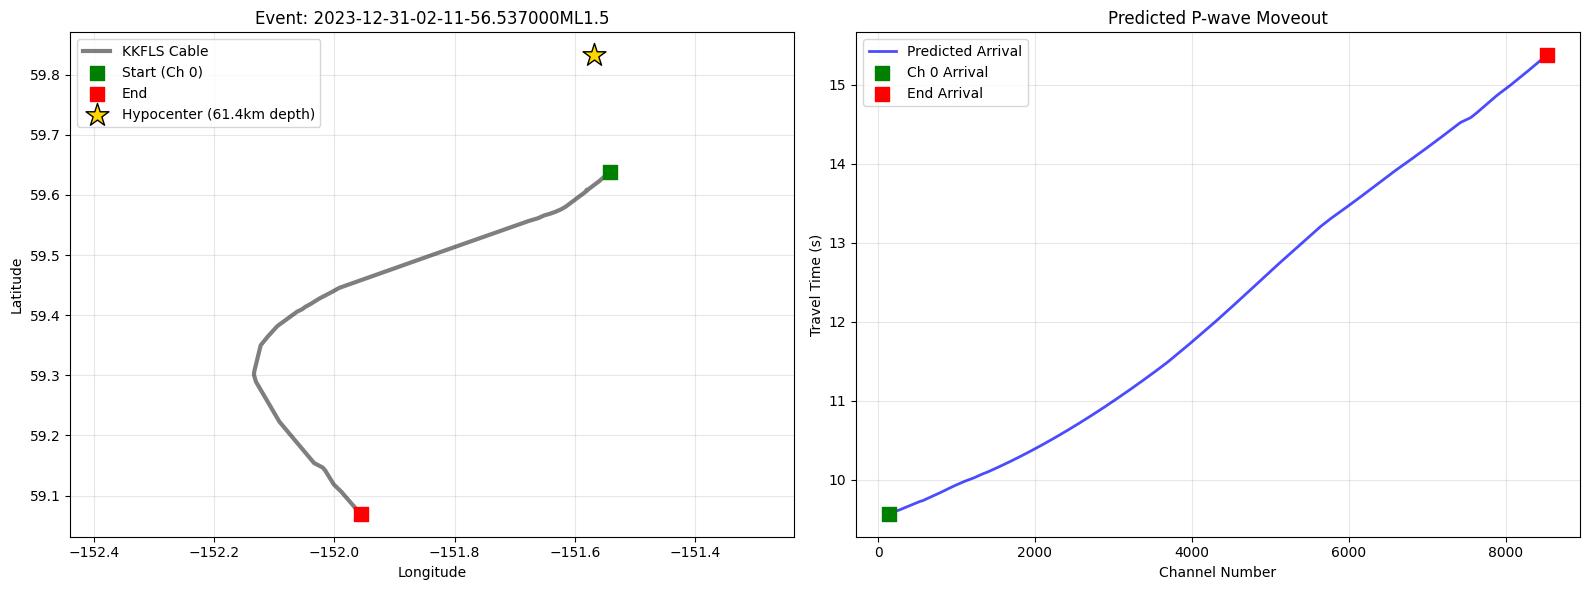

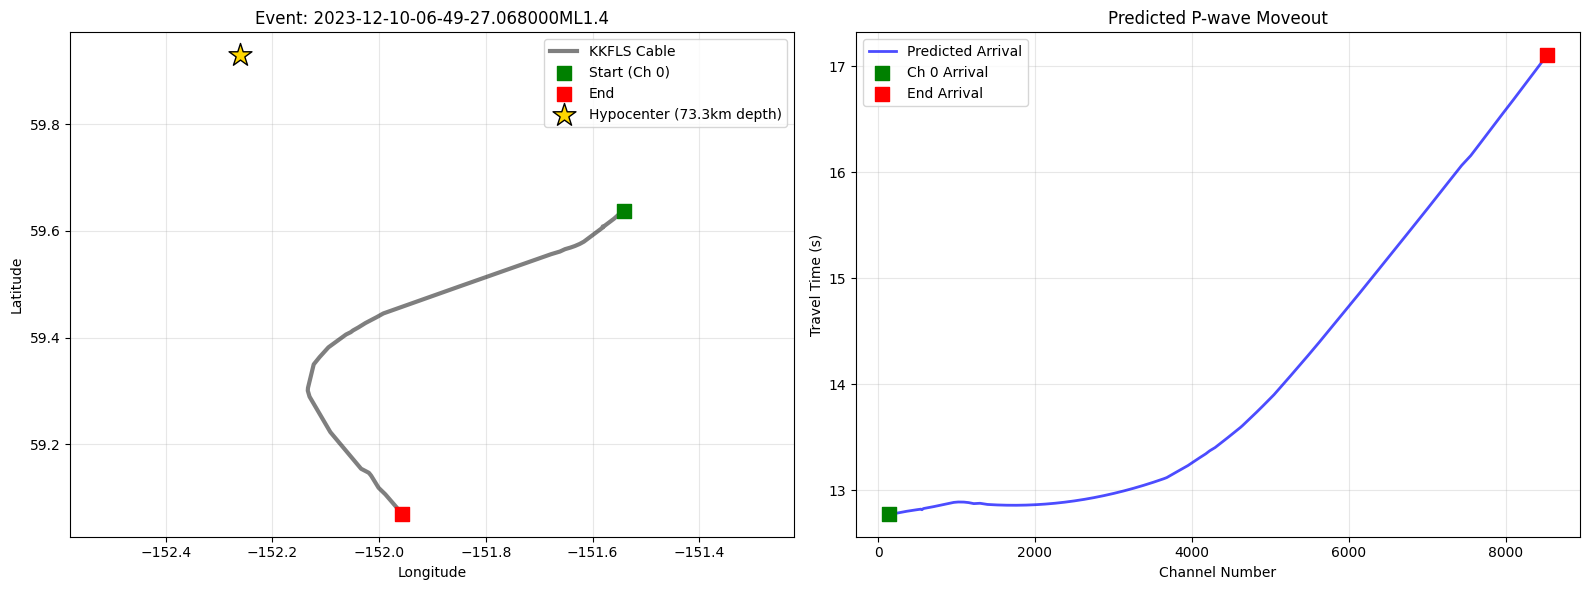

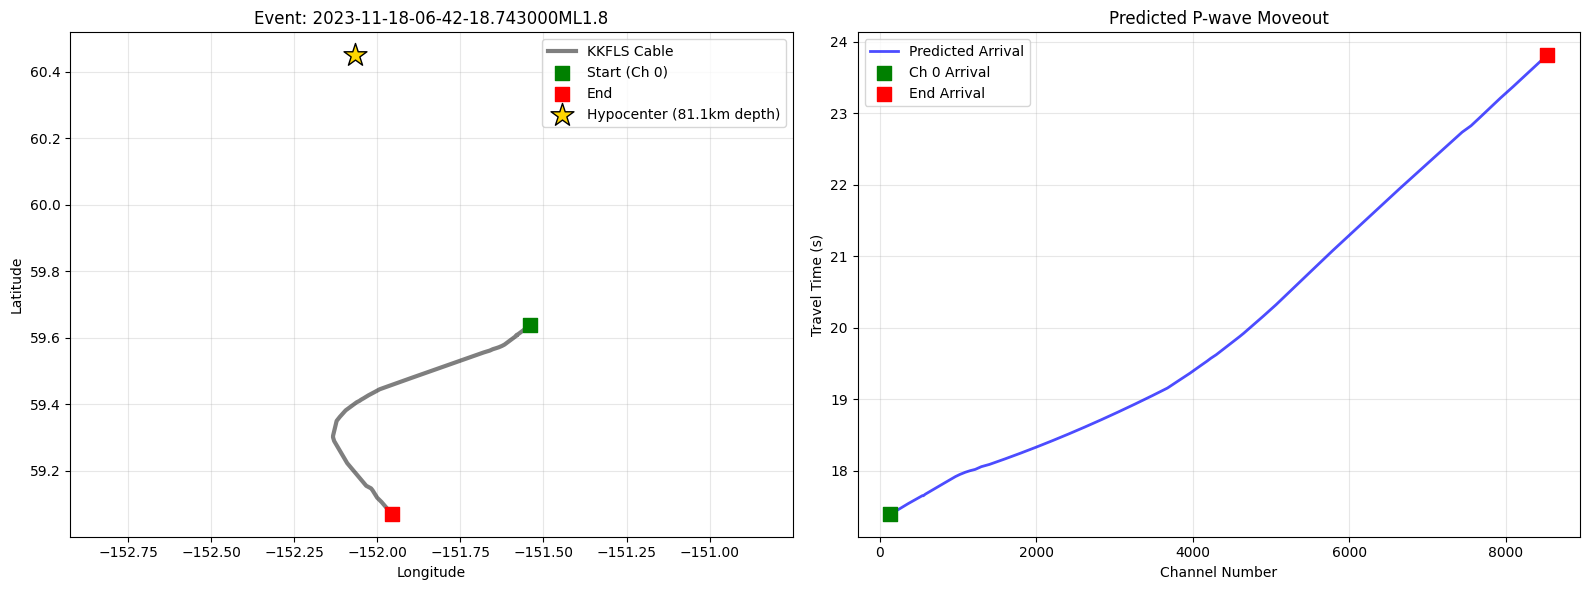

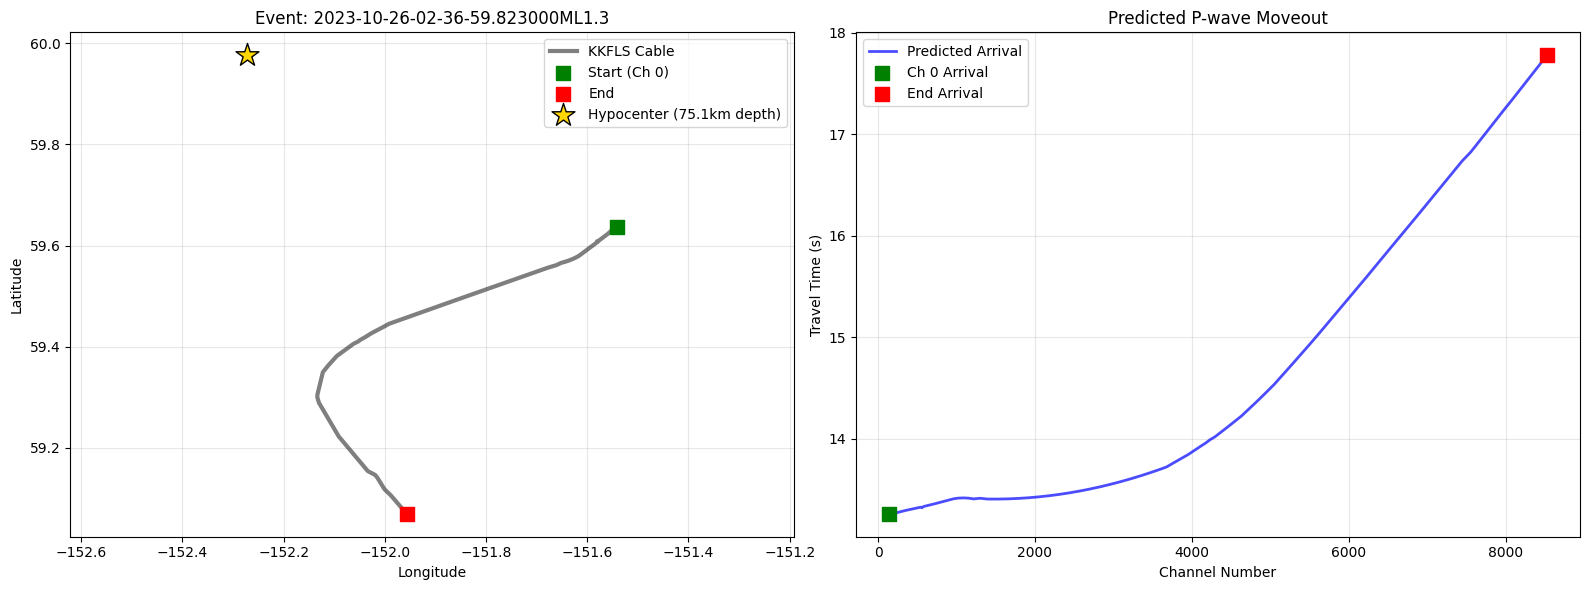

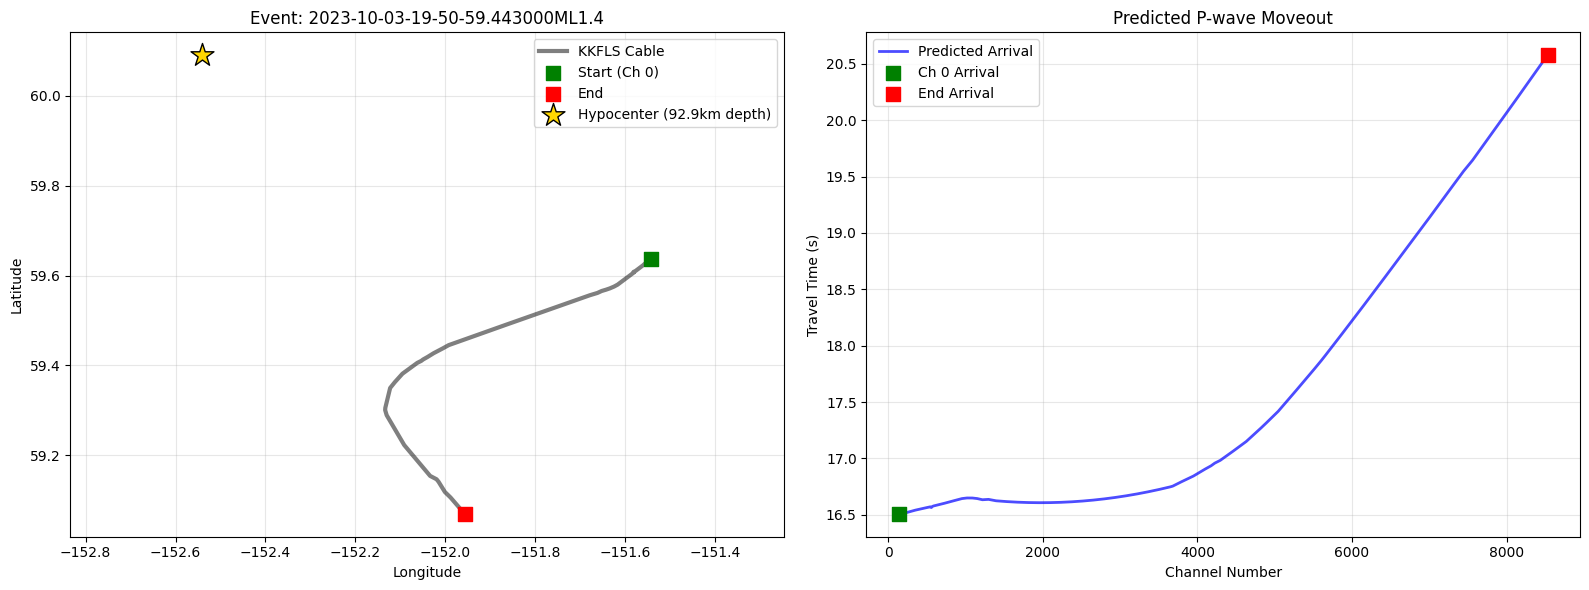

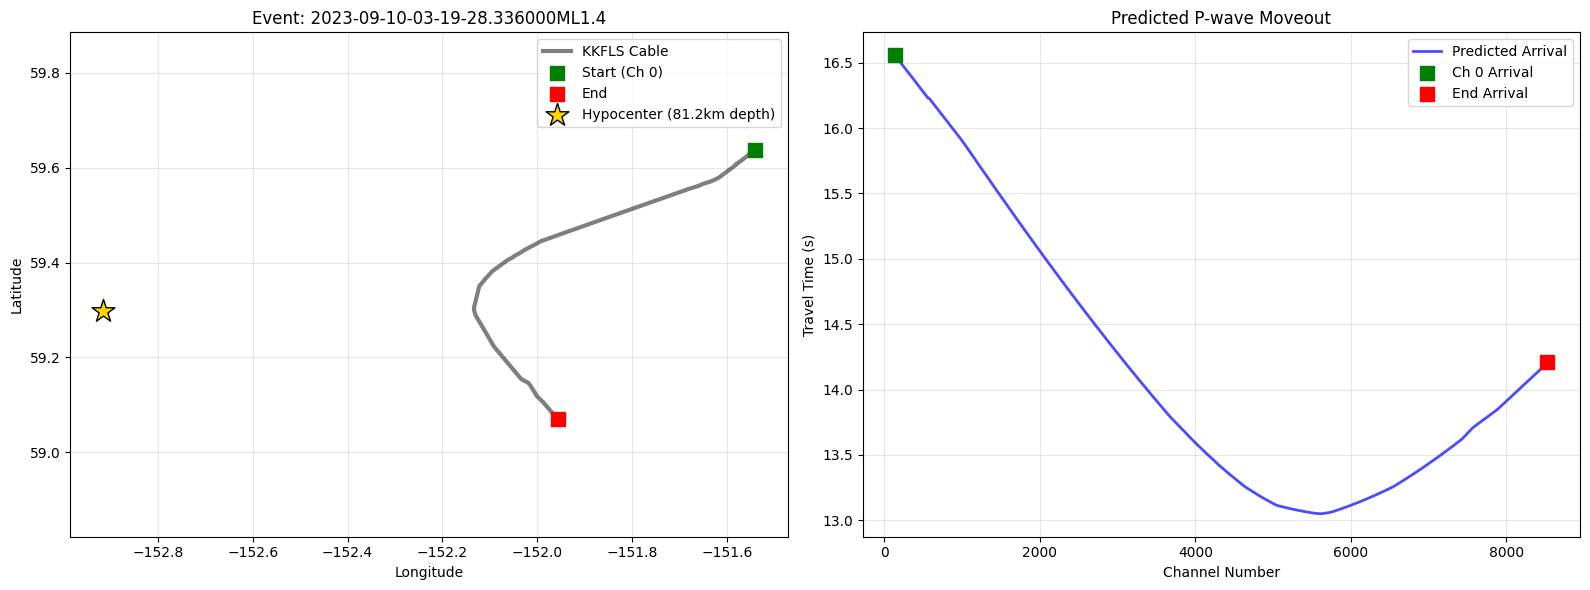

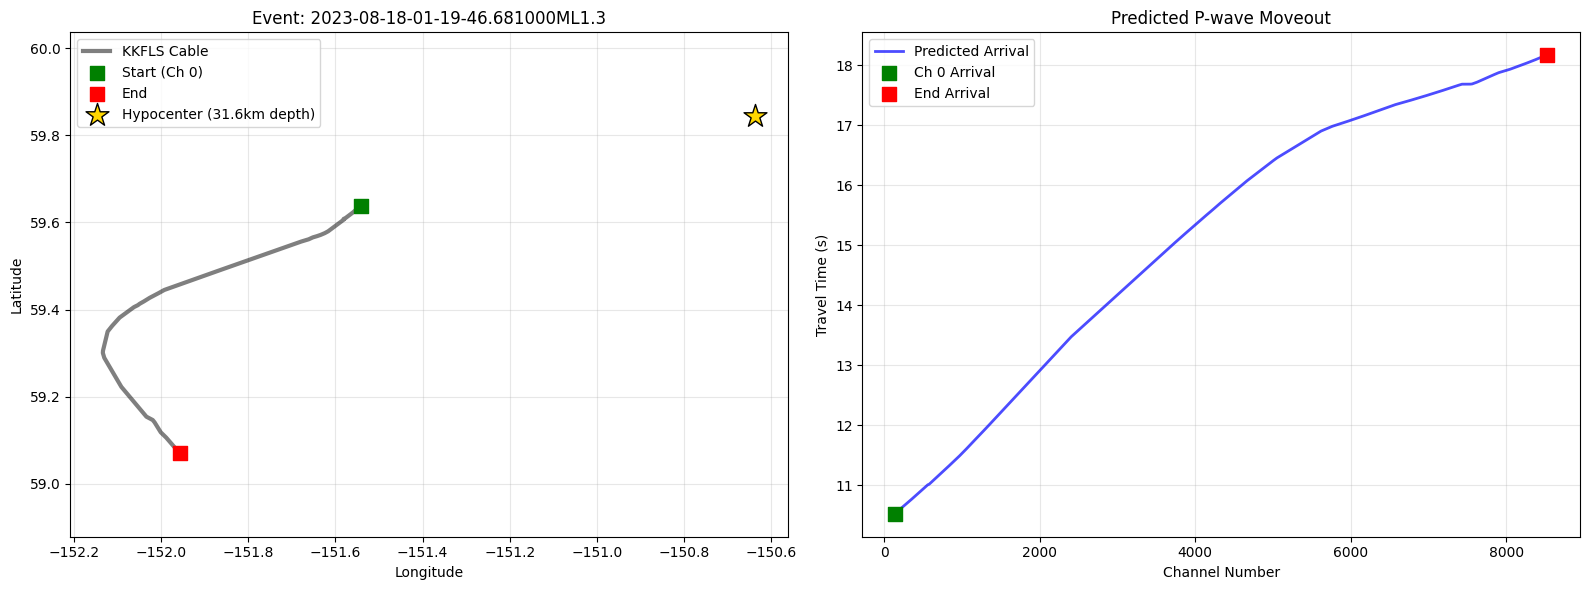

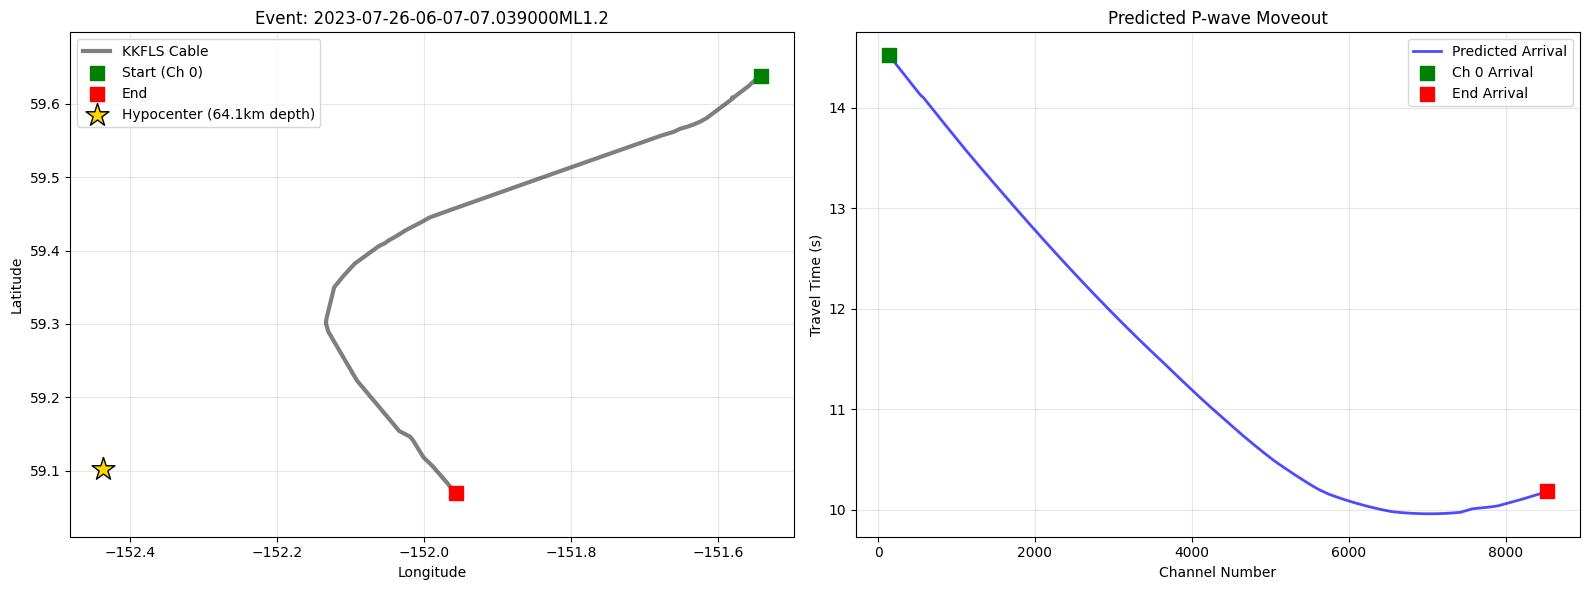

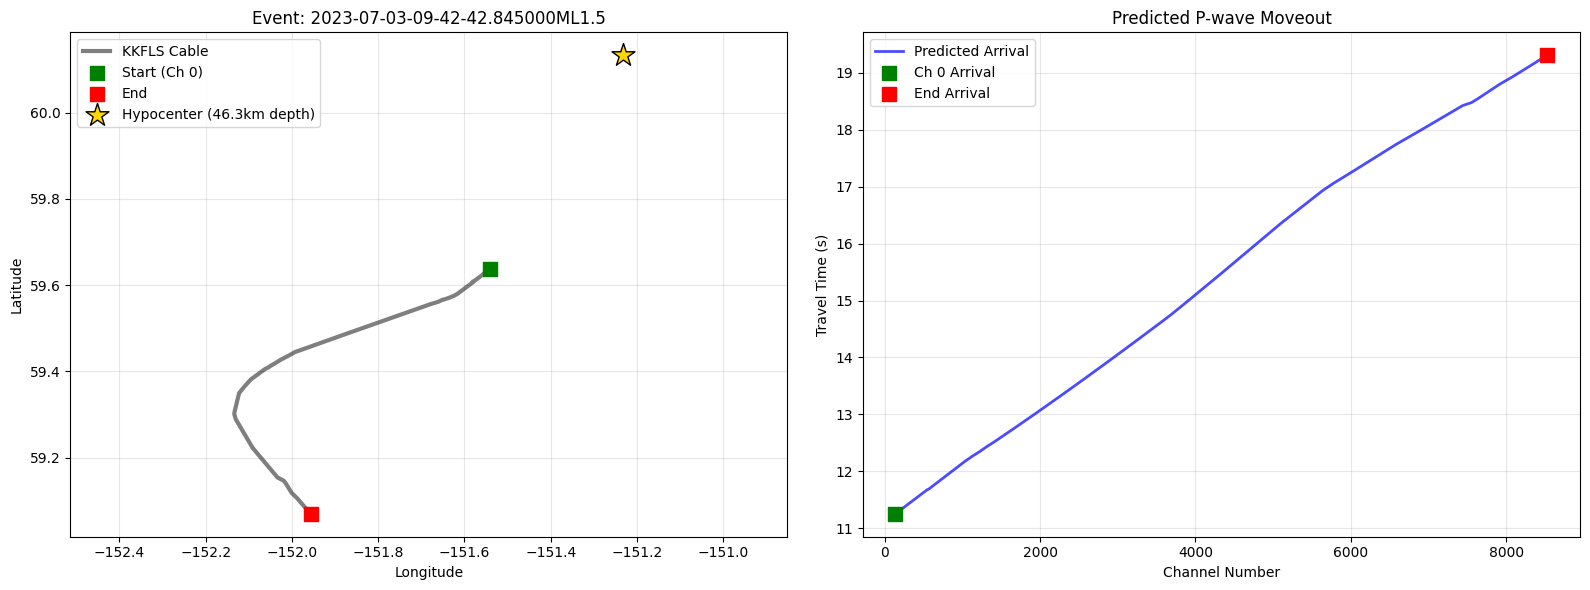

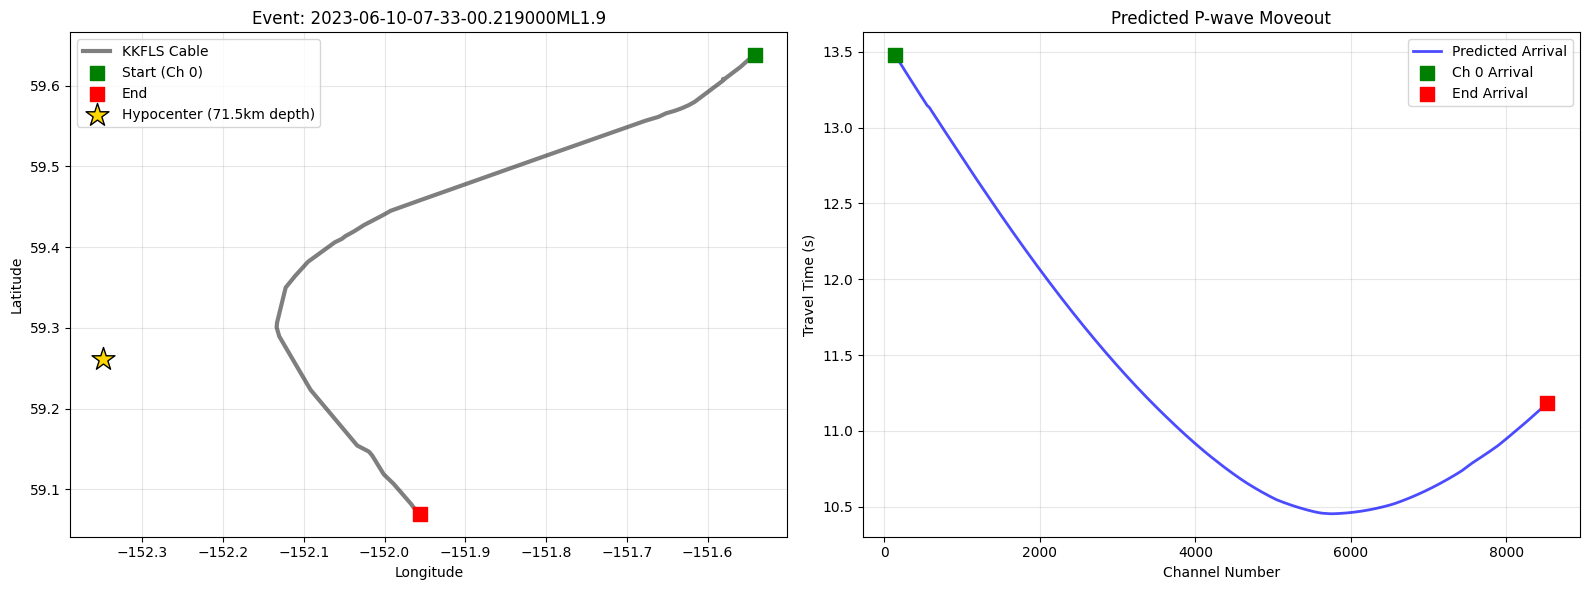

In [1]:
# TauP spaghetti maps

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees
import os
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

model = TauPyModel(model="ak135")

def load_coords(filepath):
    df = pd.read_csv(filepath, sep=r'\s+', header=None, names=['lon','lat','cha','dep']).dropna()
    df['lon'] = df['lon'].apply(lambda x: x - 360 if x > 180 else x)
    R = 6371.0
    lat, lon = np.radians(df['lat'].values), np.radians(df['lon'].values)
    dlat, dlon = np.diff(lat), np.diff(lon)
    a = np.sin(dlat/2)**2 + np.cos(lat[:-1])*np.cos(lat[1:])*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    df['dist_km'] = np.insert(R * c, 0, 0).cumsum()
    return df

event_data = {
    "2023-12-31-02-11-56.537000ML1.5": {"lat": 59.832, "lon": -151.569, "dep": 61400.0},
    "2023-12-10-06-49-27.068000ML1.4": {"lat": 59.929, "lon": -152.260, "dep": 73300.0},
    "2023-11-18-06-42-18.743000ML1.8": {"lat": 60.450, "lon": -152.067, "dep": 81100.0},
    "2023-10-26-02-36-59.823000ML1.3": {"lat": 59.976, "lon": -152.272, "dep": 75100.0},
    "2023-10-03-19-50-59.443000ML1.4": {"lat": 60.090, "lon": -152.540, "dep": 92900.0},
    "2023-09-10-03-19-28.336000ML1.4": {"lat": 59.297, "lon": -152.916, "dep": 81200.0},
    "2023-08-18-01-19-46.681000ML1.3": {"lat": 59.845, "lon": -150.637, "dep": 31600.0},
    "2023-07-26-06-07-07.039000ML1.2": {"lat": 59.103, "lon": -152.437, "dep": 64100.0},
    "2023-07-03-09-42-42.845000ML1.5": {"lat": 60.133, "lon": -151.232, "dep": 46300.0},
    "2023-06-10-07-33-00.219000ML1.9": {"lat": 59.262, "lon": -152.349, "dep": 71500.0}
}

def analyze_cable_moveout(coords_df, event_dict):
    p1 = coords_df.iloc[0]
    p2 = coords_df.iloc[-1]
    results = []
    
    print(f"{'Event ID':<32} | {'Phase':<5} | {'T_Start':<8} | {'T_End':<8} | {'Diff (s)':<8}")
    print("-" * 75)

    for eid, info in event_dict.items():
        z_km = info['dep'] / 1000.0
        dist1 = locations2degrees(info['lat'], info['lon'], p1['lat'], p1['lon'])
        dist2 = locations2degrees(info['lat'], info['lon'], p2['lat'], p2['lon'])
        
        p_phases = ["p", "P", "Pn", "Pg"]
        arr1_p = model.get_travel_times(z_km, dist1, phase_list=p_phases)
        arr2_p = model.get_travel_times(z_km, dist2, phase_list=p_phases)
        t1, t2, phase_used = None, None, None

        if len(arr1_p) > 0 and len(arr2_p) > 0:
            t1, t2 = arr1_p[0].time, arr2_p[0].time
            phase_used = "P"
        else:
            s_phases = ["s", "S", "Sn", "Sg"]
            arr1_s = model.get_travel_times(z_km, dist1, phase_list=s_phases)
            arr2_s = model.get_travel_times(z_km, dist2, phase_list=s_phases)
            if len(arr1_s) > 0 and len(arr2_s) > 0:
                t1, t2 = arr1_s[0].time, arr2_s[0].time
                phase_used = "S"

        if t1 is not None and t2 is not None:
            diff = abs(t1 - t2)
            results.append({'id': eid, 'phase': phase_used, 't1': t1, 't2': t2, 
                'diff': diff, 'dist1': dist1, 'z': z_km})
            print(f"{eid:<32} | {phase_used:<5} | {t1:>8.2f} | {t2:>8.2f} | {diff:>8.2f}")
        else:
            print(f"{eid:<32} | {'None':<5} | {'N/A':>8} | {'N/A':>8} | {'N/A':>8}")
    
    return results

base_dir = "/Users/ed/research_code/das"
kkfls_coords = load_coords(os.path.join(base_dir, 'das_coords_bathymetry/KKFLS_coords.xycz'))
moveout_data = analyze_cable_moveout(kkfls_coords, event_data)

for i, ev in enumerate(moveout_data):
    if i >= 10: break
    
    eid = ev['id']
    eq_lat = event_data[eid]['lat']
    eq_lon = event_data[eid]['lon']
    eq_depth = ev['z']
    target_phases = ["p", "P", "Pn", "Pg"] if ev['phase'] == "P" else ["s", "S", "Sn", "Sg"]
    
    fig, (ax_map, ax_time) = plt.subplots(1, 2, figsize=(16, 6))
    ax_map.plot(kkfls_coords['lon'], kkfls_coords['lat'], 'k-', linewidth=3, label='KKFLS Cable', alpha=0.5)
    ax_map.scatter(kkfls_coords['lon'].iloc[0], kkfls_coords['lat'].iloc[0], 
                   c='green', marker='s', s=100, label='Start (Ch 0)', zorder=5)
    ax_map.scatter(kkfls_coords['lon'].iloc[-1], kkfls_coords['lat'].iloc[-1], 
                   c='red', marker='s', s=100, label='End', zorder=5)
    ax_map.scatter(eq_lon, eq_lat, marker='*', s=300, c='gold', edgecolors='k', 
                   label=f'Hypocenter ({eq_depth:.1f}km depth)', zorder=6)
    ax_map.set_title(f"Event: {eid}")
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.legend(loc='best')
    ax_map.grid(True, alpha=0.3)
    ax_map.set_aspect('equal', adjustable='datalim')

    channels = kkfls_coords['cha'].values
    arrival_times = []
    for idx, row in kkfls_coords.iterrows():
        dist = locations2degrees(eq_lat, eq_lon, row['lat'], row['lon'])
        arrivals = model.get_travel_times(source_depth_in_km=eq_depth, 
                                         distance_in_degree=dist, 
                                         phase_list=target_phases)
        arrival_times.append(arrivals[0].time if arrivals else np.nan)

    ax_time.plot(channels, arrival_times, color='blue', linewidth=2, alpha=0.7, label='Predicted Arrival')
    ax_time.scatter(channels[0], arrival_times[0], c='green', marker='s', s=100, label='Ch 0 Arrival', zorder=5)
    ax_time.scatter(channels[-1], arrival_times[-1], c='red', marker='s', s=100, label='End Arrival', zorder=5)
    ax_time.set_title(f"Predicted {ev['phase']}-wave Moveout")
    ax_time.set_xlabel("Channel Number")
    ax_time.set_ylabel("Travel Time (s)")
    ax_time.legend(loc='best')
    ax_time.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()